# 🔗 Notebook 3: Merging 2 Datasets & Statistical Analysis

This notebook merges the cleaned purchases and survey datasets into a single combined DataFrame, performs post-merge cleaning, and runs statistical tests to explore relationships between consumer demographics, behaviour, and purchasing patterns.

**Inputs:**  
- `cleaned_purchases_final.csv` — output from Notebook 1  
- `cleaned_survey_dataset.csv` — output from Notebook 2  

**Output:** `Merged_Cleaned_final_dataset.csv` — the final combined dataset used for all analysis

**Sections:**
1. Importing libraries
2. Loading both cleaned datasets
3. Merging the datasets
4. Post-merge cleaning (state column, rename)
5. Final verification
6. Save merged dataset
7. Statistical Analysis
   - Test 1: Account sharing (No. of Users) vs Purchase Quantity — One-Way ANOVA
   - Test 2: Family Size vs Purchase Quantity — Two-Way ANOVA with interaction
   - Test 3: Amazon Account Usage Frequency vs Purchase Quantity — Two-Way ANOVA + Correlation

---

## 1. Importing Required Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import f_oneway
import statsmodels.api as sm
from statsmodels.formula.api import ols

## 2. Loading the Cleaned Datasets

We load both outputs from Notebooks 1 and 2.

> ⚠️ **Update both file paths to your own directory before running.**

**Expected shapes:**
- `purchases`: ~1,839,075 rows × 12 columns (after duplicate removal + date extraction + category engineering)
- `users`: 5,027 rows × 23 columns

In [2]:
purchases = pd.read_csv(r"C:\Users\vaish\Desktop\MKT 4990\cleaned_purchases_final.csv")
users = pd.read_csv(r"C:\Users\vaish\Desktop\MKT 4990\cleaned_survey_dataset.csv")
print('Purchases shape:', purchases.shape)
print('Users shape:', users.shape)

Purchases shape: (1839075, 12)
Users shape: (5027, 23)


In [3]:
purchases.head()

,User_ID,Product_ID,Category,Title,Quantity,Purchase Price Per Unit,State,Year,Month,Day,Duplicate,Brand
0,R_01vNIayewjIIKMF,B0143RTB1E,Electronics,SanDisk Ultra 16GB Class 10 SDHC UHS-I Memory ...,1.0,7.98,NJ,2018,Dec,4,No,SanDisk
1,R_01vNIayewjIIKMF,B01MA1MJ6H,Electronics,Betron BS10 Earphones Wired Headphones in Ear ...,1.0,13.99,NJ,2018,Dec,22,No,Betron BS10
2,R_01vNIayewjIIKMF,B078JZTFN3,Unknown,Unknown,1.0,8.99,NJ,2018,Dec,24,No,Unknown
3,R_01vNIayewjIIKMF,B06XWF9HML,Home-Bed-Bath,Perfecto Stainless Steel Shaving Bowl. Durable...,1.0,10.45,NJ,2018,Dec,25,No,Perfecto
4,R_01vNIayewjIIKMF,B00837ZOI0,Beauty,Proraso Shaving Cream for Men,1.0,10.00,NJ,2018,Dec,25,No,Proraso Shaving


In [4]:
users.head()

,User_ID,Age,Hispanic,Race,Education,Income,Gender,Sexual_Orientation,State,No.of Users,...,Marijuana,Alcohol,Diabetes,Wheel_Chair,Life_Changes,Sell_Data,Sell_Consumer_Data,Small_Business_Use,Census_Use,Research
0,R_1ou69fj4DQGsVcp,35 - 44 years,No,Black or African American,High school diploma or GED,"$25,000 - $49,999",Female,heterosexual (straight),Iowa,2,...,No,Yes,No,No,Lost a job,No,No,No,No,No
1,R_2UbJL30HRjK1sdD,45 - 54 years,No,White or Caucasian,High school diploma or GED,"$100,000 - $149,999",Male,heterosexual (straight),Ohio,2,...,No,No,No,No,NaN,No,No,No,No,Yes
2,R_UPXamGKtmf4RVIZ,25 - 34 years,No,White or Caucasian,High school diploma or GED,"$25,000 - $49,999",Male,heterosexual (straight),Arkansas,1 (just me!),...,No,No,Yes,No,NaN,No,No,No,No,Yes
3,R_2dYk5auG9Fv5Qve,35 - 44 years,Yes,White or Caucasian,"Graduate or professional degree (MA, MS, MBA, ...","$50,000 - $74,999",Male,heterosexual (straight),Tennessee,1 (just me!),...,No,No,No,No,NaN,No,No,No,No,No
4,R_2aP0GyIR66gSTiR,25 - 34 years,No,White or Caucasian,High school diploma or GED,"$50,000 - $74,999",Male,heterosexual (straight),Virginia,2,...,No,Yes,No,No,NaN,No,Yes if consumers get part of the profit,I don't know,No,No


## 3. Merging the Datasets

We merge purchases and users on `User_ID` using an **inner join** — keeping only users who appear in both datasets.

**Why inner join?**
- Ensures every row in the combined dataset has both purchase history and demographic data
- The 1 user present in survey but not purchases is excluded — this is expected (they opted out of sharing purchase data)

**Expected result:** ~1,839,075 rows × 34 columns, 5,026 unique users.

In [5]:
combined = pd.merge(purchases, users, on='User_ID', how='inner')

In [6]:
combined.shape

(1839075, 34)

In [7]:
combined["User_ID"].nunique()

5026

In [8]:
combined.head(5)

,User_ID,Product_ID,Category,Title,Quantity,Purchase Price Per Unit,State_x,Year,Month,Day,...,Marijuana,Alcohol,Diabetes,Wheel_Chair,Life_Changes,Sell_Data,Sell_Consumer_Data,Small_Business_Use,Census_Use,Research
0,R_01vNIayewjIIKMF,B0143RTB1E,Electronics,SanDisk Ultra 16GB Class 10 SDHC UHS-I Memory ...,1.0,7.98,NJ,2018,Dec,4,...,No,No,No,No,NaN,Yes if I get part of the profit,Yes if consumers get part of the profit,No,No,Yes
1,R_01vNIayewjIIKMF,B01MA1MJ6H,Electronics,Betron BS10 Earphones Wired Headphones in Ear ...,1.0,13.99,NJ,2018,Dec,22,...,No,No,No,No,NaN,Yes if I get part of the profit,Yes if consumers get part of the profit,No,No,Yes
2,R_01vNIayewjIIKMF,B078JZTFN3,Unknown,Unknown,1.0,8.99,NJ,2018,Dec,24,...,No,No,No,No,NaN,Yes if I get part of the profit,Yes if consumers get part of the profit,No,No,Yes
3,R_01vNIayewjIIKMF,B06XWF9HML,Home-Bed-Bath,Perfecto Stainless Steel Shaving Bowl. Durable...,1.0,10.45,NJ,2018,Dec,25,...,No,No,No,No,NaN,Yes if I get part of the profit,Yes if consumers get part of the profit,No,No,Yes
4,R_01vNIayewjIIKMF,B00837ZOI0,Beauty,Proraso Shaving Cream for Men,1.0,10.00,NJ,2018,Dec,25,...,No,No,No,No,NaN,Yes if I get part of the profit,Yes if consumers get part of the profit,No,No,Yes


## 4. Post-Merge Cleaning

- After merging, there is an issue with the `State` column. 
- As both the datasets have column name `State`, the merged dataset has 2 different state columns: `State_x` and `State_y`.

### 4.1 Duplicate State Columns

The merge produces two state columns:
- `State_x` — the **shipping state** from the purchases dataset (U.S. state abbreviation, e.g. `"NJ"`)
- `State_y` — the **home state** from the survey dataset (full state name, e.g. `"New Jersey"`)

These are different fields — `State_x` tells us where items were shipped; `State_y` tells us where the user lives. We first standardise `State_y` from full names to abbreviations using a state mapping dictionary, then rename both columns to avoid confusion.

In [9]:
state_map = {
    "Alabama": "AL", "Alaska": "AK", "Arizona": "AZ", "Arkansas": "AR",
    "California": "CA", "Colorado": "CO", "Connecticut": "CT", "Delaware": "DE",
    "District of Columbia": "DC", "Florida": "FL", "Georgia": "GA",
    "Hawaii": "HI", "Idaho": "ID", "Illinois": "IL", "Indiana": "IN",
    "Iowa": "IA", "Kansas": "KS", "Kentucky": "KY", "Louisiana": "LA",
    "Maine": "ME", "Maryland": "MD", "Massachusetts": "MA", "Michigan": "MI",
    "Minnesota": "MN", "Mississippi": "MS", "Missouri": "MO", "Montana": "MT",
    "Nebraska": "NE", "Nevada": "NV", "New Hampshire": "NH", "New Jersey": "NJ",
    "New Mexico": "NM", "New York": "NY", "North Carolina": "NC",
    "North Dakota": "ND", "Ohio": "OH", "Oklahoma": "OK", "Oregon": "OR",
    "Pennsylvania": "PA", "Rhode Island": "RI", "South Carolina": "SC",
    "South Dakota": "SD", "Tennessee": "TN", "Texas": "TX", "Utah": "UT",
    "Vermont": "VT", "Virginia": "VA", "Washington": "WA",
    "West Virginia": "WV", "Wisconsin": "WI", "Wyoming": "WY",
    "American Samoa": "AS", "Guam": "GU", "Northern Mariana Islands": "MP",
    "Puerto Rico": "PR", "Virgin Islands": "VI", "Trust Territories": "TT"
}


In [10]:
combined["State_y"] = combined["State_y"].replace(state_map)


In [11]:
combined["State_y"]

0          NJ
1          NJ
2          NJ
3          NJ
4          NJ
           ..
1839070    MA
1839071    MA
1839072    MA
1839073    MA
1839074    MA
Name: State_y, Length: 1839075, dtype: object

### 4.3 Rename State Columns

We rename `State_x` → `Order_State` and `State_y` → `State` to make the distinction explicit and self-documenting for all downstream analysis.

In [12]:
combined.rename(columns={'State_x':'Order_State','State_y':'State'})

,User_ID,Product_ID,Category,Title,Quantity,Purchase Price Per Unit,Order_State,Year,Month,Day,...,Marijuana,Alcohol,Diabetes,Wheel_Chair,Life_Changes,Sell_Data,Sell_Consumer_Data,Small_Business_Use,Census_Use,Research
0,R_01vNIayewjIIKMF,B0143RTB1E,Electronics,SanDisk Ultra 16GB Class 10 SDHC UHS-I Memory ...,1.0,7.98,NJ,2018,Dec,4,...,No,No,No,No,NaN,Yes if I get part of the profit,Yes if consumers get part of the profit,No,No,Yes
1,R_01vNIayewjIIKMF,B01MA1MJ6H,Electronics,Betron BS10 Earphones Wired Headphones in Ear ...,1.0,13.99,NJ,2018,Dec,22,...,No,No,No,No,NaN,Yes if I get part of the profit,Yes if consumers get part of the profit,No,No,Yes
2,R_01vNIayewjIIKMF,B078JZTFN3,Unknown,Unknown,1.0,8.99,NJ,2018,Dec,24,...,No,No,No,No,NaN,Yes if I get part of the profit,Yes if consumers get part of the profit,No,No,Yes
3,R_01vNIayewjIIKMF,B06XWF9HML,Home-Bed-Bath,Perfecto Stainless Steel Shaving Bowl. Durable...,1.0,10.45,NJ,2018,Dec,25,...,No,No,No,No,NaN,Yes if I get part of the profit,Yes if consumers get part of the profit,No,No,Yes
4,R_01vNIayewjIIKMF,B00837ZOI0,Beauty,Proraso Shaving Cream for Men,1.0,10.00,NJ,2018,Dec,25,...,No,No,No,No,NaN,Yes if I get part of the profit,Yes if consumers get part of the profit,No,No,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1839070,R_zfqnsBzlOAKibzb,B015ZRTHVA,Home-Bed-Bath,Tanner's Tasty Paste Vanilla Bling - Anticavit...,1.0,6.99,MA,2021,Apr,1,...,No,No,No,Yes,NaN,No,No,Yes,I don't know,Yes
1839071,R_zfqnsBzlOAKibzb,B00QGCXPRG,Home-Bed-Bath,Sinland Microfiber Cleaning Cloth Dish Cloth K...,1.0,15.99,MA,2021,Apr,14,...,No,No,No,Yes,NaN,No,No,Yes,I don't know,Yes
1839072,R_zfqnsBzlOAKibzb,B015ZRTHVA,Home-Bed-Bath,Tanner's Tasty Paste Vanilla Bling - Anticavit...,4.0,6.99,MA,2021,May,22,...,No,No,No,Yes,NaN,No,No,Yes,I don't know,Yes
1839073,R_zfqnsBzlOAKibzb,B015ZRTHVA,Home-Bed-Bath,Tanner's Tasty Paste Vanilla Bling - Anticavit...,4.0,6.99,MA,2021,Dec,1,...,No,No,No,Yes,NaN,No,No,Yes,I don't know,Yes


## 5. Final Dataset Verification

Three checks before saving:

1. **Shape** — confirms row and column count
2. **Missing values** — only `Life Changes` (~1231070 NaNs) should remain; all other columns complete
3. **Unique value counts** — confirms `Category` has ~26 unique values, `User_ID` has 5,026

In [13]:
combined.shape

(1839075, 34)

In [14]:
combined.isnull().sum()

User_ID                          0
Product_ID                       0
Category                         0
Title                            0
Quantity                         0
Purchase Price Per Unit          0
State_x                          0
Year                             0
Month                            0
Day                              0
Duplicate                        0
Brand                          708
Age                              0
Hispanic                         0
Race                             0
Education                        0
Income                           0
Gender                           0
Sexual_Orientation               0
State_y                          0
No.of Users                      0
Family Size                      0
Acc Usage                        0
Cigarettes                       0
Marijuana                        0
Alcohol                          0
Diabetes                         0
Wheel_Chair                      0
Life_Changes        

In [15]:
combined.nunique()

User_ID                      5026
Product_ID                 939073
Category                       26
Title                      824711
Quantity                       69
Purchase Price Per Unit     18282
State_x                        53
Year                            6
Month                          12
Day                            31
Duplicate                       2
Brand                      194384
Age                             6
Hispanic                        2
Race                           25
Education                       5
Income                          7
Gender                          4
Sexual_Orientation              3
State_y                        52
No.of Users                     4
Family Size                     4
Acc Usage                       3
Cigarettes                      4
Marijuana                       4
Alcohol                         4
Diabetes                        3
Wheel_Chair                     3
Life_Changes                   22
Sell_Data     

In [16]:
combined['Brand'] = combined['Brand'].fillna("Unknown")

In [17]:
combined.head()

,User_ID,Product_ID,Category,Title,Quantity,Purchase Price Per Unit,State_x,Year,Month,Day,...,Marijuana,Alcohol,Diabetes,Wheel_Chair,Life_Changes,Sell_Data,Sell_Consumer_Data,Small_Business_Use,Census_Use,Research
0,R_01vNIayewjIIKMF,B0143RTB1E,Electronics,SanDisk Ultra 16GB Class 10 SDHC UHS-I Memory ...,1.0,7.98,NJ,2018,Dec,4,...,No,No,No,No,NaN,Yes if I get part of the profit,Yes if consumers get part of the profit,No,No,Yes
1,R_01vNIayewjIIKMF,B01MA1MJ6H,Electronics,Betron BS10 Earphones Wired Headphones in Ear ...,1.0,13.99,NJ,2018,Dec,22,...,No,No,No,No,NaN,Yes if I get part of the profit,Yes if consumers get part of the profit,No,No,Yes
2,R_01vNIayewjIIKMF,B078JZTFN3,Unknown,Unknown,1.0,8.99,NJ,2018,Dec,24,...,No,No,No,No,NaN,Yes if I get part of the profit,Yes if consumers get part of the profit,No,No,Yes
3,R_01vNIayewjIIKMF,B06XWF9HML,Home-Bed-Bath,Perfecto Stainless Steel Shaving Bowl. Durable...,1.0,10.45,NJ,2018,Dec,25,...,No,No,No,No,NaN,Yes if I get part of the profit,Yes if consumers get part of the profit,No,No,Yes
4,R_01vNIayewjIIKMF,B00837ZOI0,Beauty,Proraso Shaving Cream for Men,1.0,10.00,NJ,2018,Dec,25,...,No,No,No,No,NaN,Yes if I get part of the profit,Yes if consumers get part of the profit,No,No,Yes


## 6. Save the Merged Dataset

Saves the final combined dataset as `Merged_Cleaned_final_dataset.csv`. This is the master file for all statistical analysis below and any further analysis notebooks.

> ⚠️ **Update the path to your own directory.**

In [18]:
combined.to_csv(
    r"C:\Users\vaish\Desktop\MKT 4990\Merged_Cleaned_final_dataset.csv"
)

---
## 7. Statistical Analysis

We load the merged dataset and run three statistical tests to explore how consumer characteristics relate to purchasing behaviour.

> ⚠️ **Update the file path to your own directory.**

In [24]:
import pandas as pd

In [25]:
df = pd.read_csv("C://Users//vaish//Desktop//MKT 4990//Merged_Cleaned_final_dataset.csv")

In [26]:
df.head()

,Unnamed: 0,User_ID,Product ID,Category,Title,Quantity,Purchase Price Per Unit,State_x,Year,Month,...,Marijuana,Alcohol,Diabetes,Wheel_Chair,Life_Changes,Sell_Data,Sell_Consumer_Data,Small_Business_Use,Census_Use,Research
0,0,R_01vNIayewjIIKMF,B0143RTB1E,Electronics,SanDisk Ultra 16GB Class 10 SDHC UHS-I Memory ...,1.0,7.98,NJ,2018,Dec,...,No,No,No,No,NaN,Yes if I get part of the profit,Yes if consumers get part of the profit,No,No,Yes
1,1,R_01vNIayewjIIKMF,B01MA1MJ6H,Electronics,Betron BS10 Earphones Wired Headphones in Ear ...,1.0,13.99,NJ,2018,Dec,...,No,No,No,No,NaN,Yes if I get part of the profit,Yes if consumers get part of the profit,No,No,Yes
2,2,R_01vNIayewjIIKMF,B078JZTFN3,Unknown,Unknown,1.0,8.99,NJ,2018,Dec,...,No,No,No,No,NaN,Yes if I get part of the profit,Yes if consumers get part of the profit,No,No,Yes
3,3,R_01vNIayewjIIKMF,B06XWF9HML,Home-Bed-Bath,Perfecto Stainless Steel Shaving Bowl. Durable...,1.0,10.45,NJ,2018,Dec,...,No,No,No,No,NaN,Yes if I get part of the profit,Yes if consumers get part of the profit,No,No,Yes
4,4,R_01vNIayewjIIKMF,B00837ZOI0,Beauty,Proraso Shaving Cream for Men,1.0,10.00,NJ,2018,Dec,...,No,No,No,No,NaN,Yes if I get part of the profit,Yes if consumers get part of the profit,No,No,Yes


In [27]:
df.columns

Index(['Unnamed: 0', 'User_ID', 'Product ID', 'Category', 'Title', 'Quantity',
       'Purchase Price Per Unit', 'State_x', 'Year', 'Month', 'Day',
       'Duplicate', 'Age', 'Hispanic', 'Race', 'Education', 'Income', 'Gender',
       'Sexual_Orientation', 'State_y', 'No.of Users', 'Family Size',
       'Acc Usage', 'Cigarettes', 'Marijuana', 'Alcohol', 'Diabetes',
       'Wheel_Chair', 'Life_Changes', 'Sell_Data', 'Sell_Consumer_Data',
       'Small_Business_Use', 'Census_Use', 'Research'],
      dtype='object')

### Test 1: Account Sharing (No. of Users) vs Purchase Quantity — One-Way ANOVA

**Research Question:** Does the number of people sharing an Amazon account affect how much they purchase?

**Variable:**
- Independent: `No. of Users` (categorical — number of people sharing the account: 1, 2, 3, etc.)
- Dependent: `Quantity` (number of units per order)

**Method:** One-Way ANOVA (`f_oneway` from `scipy.stats`)

**Hypothesis:**
- H₀: Mean purchase quantity is the same across all account-sharing groups
- H₁: At least one group has a significantly different mean purchase quantity

**Interpretation guide:** If p-value < 0.05, we reject H₀ and conclude that account sharing size has a statistically significant effect on purchase quantity.

In [28]:
group1 = df.groupby('No.of Users')['Quantity'].agg(['sum','mean','count'])
print(group1)

                    sum      mean   count
No.of Users                              
1 (just me!)  1088549.0  1.088594  999959
2              637405.0  1.090377  584573
3              165216.0  1.090887  151451
4+             111346.0  1.080064  103092


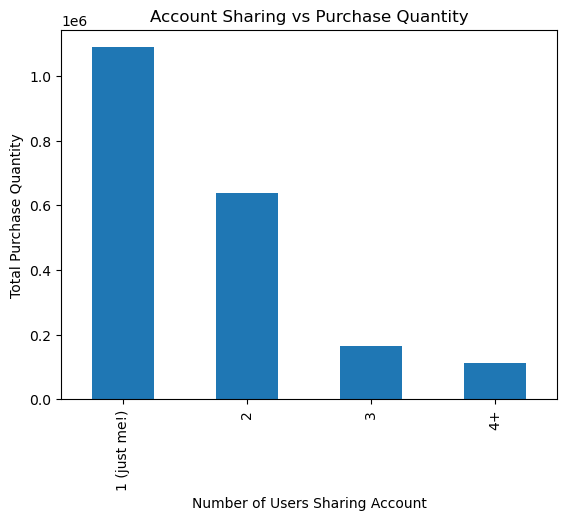

In [29]:
import matplotlib.pyplot as plt

group1['sum'].plot(kind='bar')
plt.xlabel('Number of Users Sharing Account')
plt.ylabel('Total Purchase Quantity')
plt.title('Account Sharing vs Purchase Quantity')
plt.show()

In [30]:
from scipy.stats import f_oneway

groups = [g['Quantity'].values for _, g in df.groupby('No.of Users')]
f_stat, p_val = f_oneway(*groups)

print("F-stat:", f_stat)
print("p-value:", p_val)

F-stat: 5.476764716500737
p-value: 0.0009254249842029225


### Test 2: Family Size vs Purchase Quantity — Two-Way ANOVA with Interaction

**Research Question:** Does family size affect purchase quantity, and does income moderate this relationship?

**Variables:**
- Independent 1: `Family Size` (categorical — household size)
- Independent 2: `Income` (categorical — income bracket)
- Dependent: `Quantity`

**Method:** Two-Way ANOVA with interaction term using `statsmodels.formula.api.ols`

**Model:** `Quantity ~ C(family_size_clean) + C(Income) + C(family_size_clean):C(Income)`

The interaction term `C(family_size_clean):C(Income)` tests whether the effect of family size on purchasing differs depending on income level — i.e., do higher-income larger families buy more than lower-income larger families?

**Interpretation guide:**
- A significant main effect for `Family Size` → family size alone drives quantity differences
- A significant interaction term → the effect of family size depends on income level

In [31]:
import pandas as pd

# Copy dataset
df2 = df.copy()

# Clean Family Size (extract numeric)
df2['family_size_clean'] = df2['Family Size'].str.extract(r'(\d+)')

# Standardize "4+" case if exists
df2['family_size_clean'] = df2['family_size_clean'].replace('4', '4+')

# Convert to category
df2['family_size_clean'] = df2['family_size_clean'].astype('category')


# Clean Age Group (already grouped, just simplify text)
df2['age_group'] = df2['Age'].str.replace(' years', '', regex=False)

df2['age_group'] = df2['age_group'].astype('category')


# Ensure Quantity is numeric
df2['Quantity'] = pd.to_numeric(df2['Quantity'], errors='coerce')

# Drop missing values
df2 = df2.dropna(subset=['family_size_clean', 'age_group', 'Quantity'])

In [32]:
import statsmodels.api as sm
from statsmodels.formula.api import ols

# Build model (with interaction)
model = ols('Quantity ~ C(family_size_clean) + C(age_group) + C(family_size_clean):C(age_group)', data=df2).fit()

# ANOVA table
anova_table = sm.stats.anova_lm(model, typ=2)

print(anova_table)

                                         sum_sq         df           F  \
C(family_size_clean)               3.223094e+01        3.0   17.635511   
C(age_group)                       4.142357e+02        5.0  135.992158   
C(family_size_clean):C(age_group)  1.097183e+02       15.0   12.006715   
Residual                           1.120360e+06  1839051.0         NaN   

                                          PR(>F)  
C(family_size_clean)                1.920145e-11  
C(age_group)                       1.124345e-144  
C(family_size_clean):C(age_group)   2.277405e-30  
Residual                                     NaN  


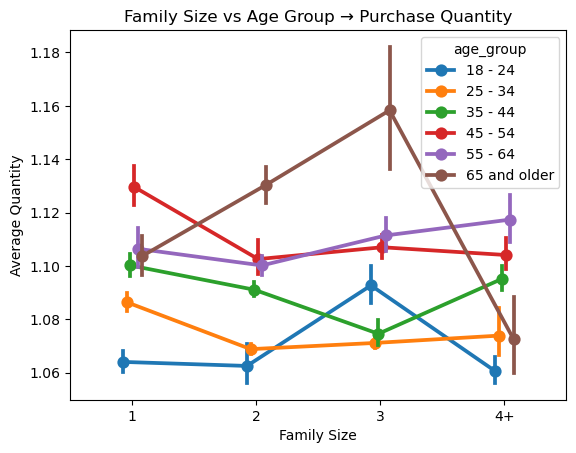

In [33]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure()

sns.pointplot(data=df2,
              x='family_size_clean',
              y='Quantity',
              hue='age_group',
              dodge=True)

plt.title('Family Size vs Age Group → Purchase Quantity')
plt.xlabel('Family Size')
plt.ylabel('Average Quantity')

plt.show()

In [34]:
group2 = df.groupby('Family Size')['Quantity'].agg(['sum','mean','count'])
print(group2)

                   sum      mean   count
Family Size                             
1 (just me!)  385917.0  1.095518  352269
2             644124.0  1.085782  593235
3             382357.0  1.085427  352264
4+            590118.0  1.090172  541307


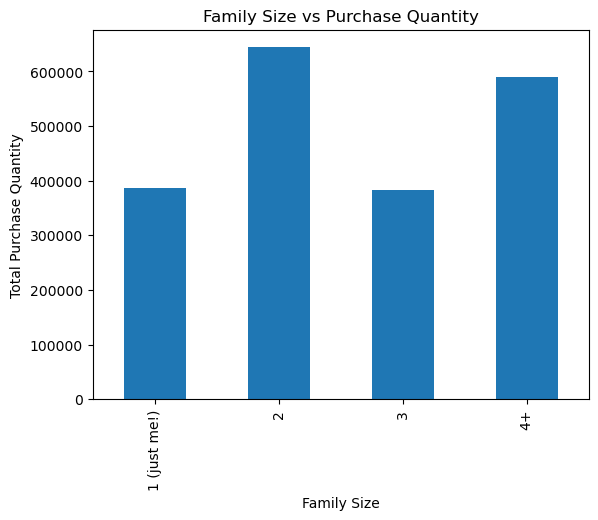

In [35]:
group2['sum'].plot(kind='bar')
plt.xlabel('Family Size')
plt.ylabel('Total Purchase Quantity')
plt.title('Family Size vs Purchase Quantity')
plt.show()

In [36]:
groups = [g['Quantity'].values for _, g in df.groupby('Family Size')]
f_stat, p_val = f_oneway(*groups)

In [37]:

print("F-stat:", f_stat)
print("p-value:", p_val)

F-stat: 14.393509735077638
p-value: 2.2536469978397846e-09


### Test 3: Amazon Account Usage Frequency vs Purchase Quantity — Two-Way ANOVA + Correlation

**Research Question:** Does how frequently a user logs into their Amazon account relate to how much they purchase? And does income moderate this?

**Variables:**
- Independent 1: `Acc Usage` (categorical — account login frequency: `"Less than 5 times per month"`, `"5–10 times per month"`, `"More than 10 times per month"`)
- Independent 2: `Income` (categorical)
- Dependent: `Quantity`

**Methods:**
1. **Two-Way ANOVA with interaction** — tests whether usage frequency and income jointly affect quantity
2. **Pearson Correlation** — after encoding `Acc Usage` numerically, we check the linear correlation with `Quantity`

**Usage encoding for correlation:**
- `5–10 times per month` → 1
- `Less than 5 times per month` → 2  
- `More than 10 times per month` → 3

**Interpretation guide:**
- Significant ANOVA interaction → income moderates the usage-quantity relationship
- Near-zero correlation → usage frequency has little to no linear relationship with quantity per order (purchasing frequency vs order size are different things)

In [38]:
print(df['Acc Usage'].unique())

['Less than 5 times per month' 'More than 10 times per month'
 '5 - 10 times per month']


In [39]:
import pandas as pd

df2 = df.copy()

# Clean Acc Usage (already categorical, just convert)
df2['Acc Usage'] = df2['Acc Usage'].astype('category')

# Clean Income (categorical)
df2['Income'] = df2['Income'].astype('category')

# Ensure Quantity is numeric
df2['Quantity'] = pd.to_numeric(df2['Quantity'], errors='coerce')

# Drop missing values
df2 = df2.dropna(subset=['Acc Usage', 'Income', 'Quantity'])

In [40]:
import statsmodels.api as sm
from statsmodels.formula.api import ols

# Build model
model = ols('Quantity ~ C(Q("Acc Usage")) + C(Income) + C(Q("Acc Usage")):C(Income)', data=df2).fit()

# ANOVA table
anova_table = sm.stats.anova_lm(model, typ=2)

print(anova_table)

                                   sum_sq         df          F        PR(>F)
C(Q("Acc Usage"))            1.006855e+01        2.0   8.261329  2.583250e-04
C(Income)                    1.134209e+02        6.0  31.020929  1.702779e-37
C(Q("Acc Usage")):C(Income)  9.766488e+01       12.0  13.355806  4.642462e-28
Residual                     1.120680e+06  1839054.0        NaN           NaN


In [41]:
group3 = df.groupby('Acc Usage')['Quantity'].agg(['sum','mean','count'])
print(group3)

                                   sum      mean   count
Acc Usage                                               
5 - 10 times per month        837814.0  1.090638  768187
Less than 5 times per month   753594.0  1.084876  694636
More than 10 times per month  411108.0  1.092640  376252


In [42]:
mapping = {
    '5 - 10 times per month':1,
    'Less than 5 times per month':2,
    'More than 10 times per month':3
}

df['Usage_Num'] = df['Acc Usage'].map(mapping)

In [43]:
corr = df[['Usage_Num','Quantity']].corr()
print(corr)

           Usage_Num  Quantity
Usage_Num   1.000000  0.000056
Quantity    0.000056  1.000000
